In [57]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
import astroML.stats

In [58]:
#0 is a cloudy day
#1 is a sunny day 

N=100000

def Markov ():
    
    today=0                 #cloudy day 
    cloudy_counts=0
    sunny_counts=0


    #Evolution of the probability for different N 
    Ps=[]              
    Pc=[]


    for i in range(1,N):

        if today ==0:
            p=np.random.uniform(0,1)
            if p<=0.5:
                today=0
            else :
                today=1
        else : 
            p=np.random.uniform(0,1)
            if p<=0.1:
                today=0
            else :
                today=1
        
        if today ==0:
            cloudy_counts+=1
        else :
            sunny_counts+=1
        
        Ps.append(sunny_counts/i)
        Pc.append(cloudy_counts/i)

    return Ps,Pc



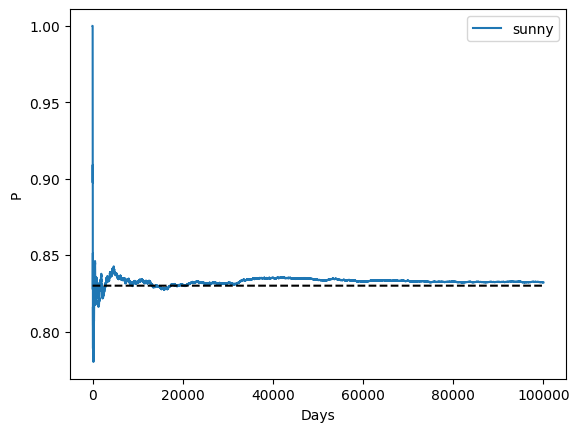

In [ ]:
x=np.linspace(1,N,N-1)
Ps=Markov()[0]
plt.plot(x,Ps, label= "sunny")
plt.plot(x,0.83*np.ones(len(x)), '--', color='black') #theoretical value
plt.xlabel("Days")
plt.legend()
plt.show()


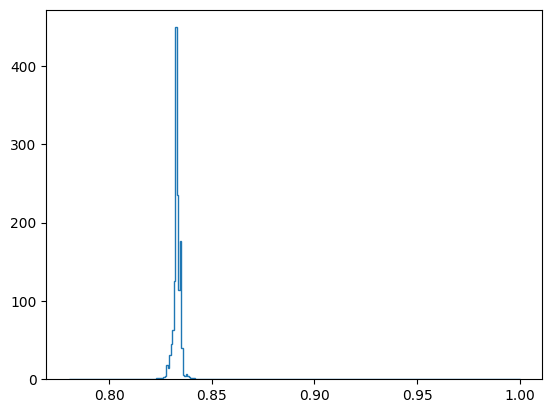

In [60]:
plt.hist(Ps, 300, density=True, histtype='step'); #distribution of P(sunny)

In [61]:
print(np.median(Ps))
print(astroML.stats.sigmaG(Ps))
print(min(Ps),max(Ps))

0.8326811939981973
0.0011027816120108718
0.7801047120418848 1.0


### Burning phase exploration

Let's cut 20000 points

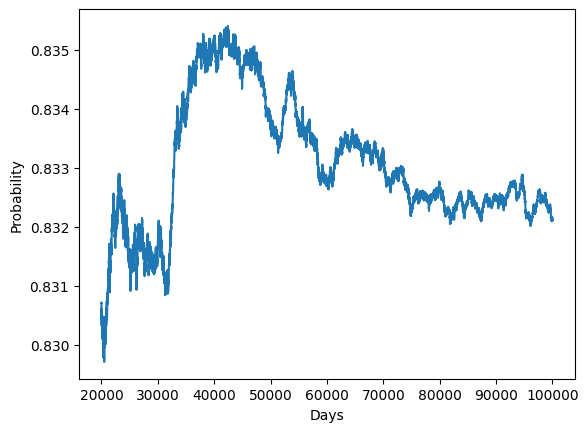

In [62]:
burn = 20000
plt.plot(x[burn:],Ps[burn:])
plt.xlabel("Days")
plt.ylabel("Probability")
plt.show()


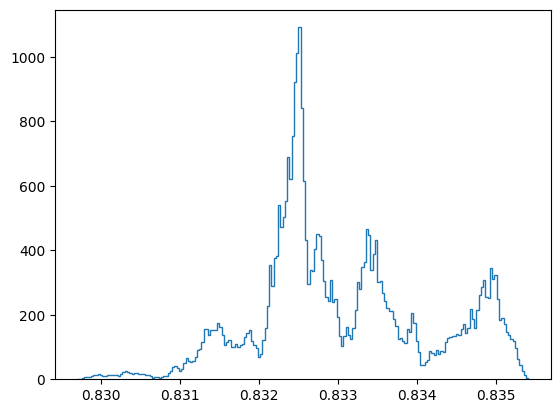

In [63]:
plt.hist(Ps[burn:], 200, density=True, histtype='step'); #distribution of P(sunny)

In [64]:
print(np.median(Ps[burn:]))
print(astroML.stats.sigmaG(Ps[burn:]))
print(min(Ps[burn:]),max(Ps[burn:]))

0.8327673543311543
0.0009879306468746905
0.8297062554894116 0.83541082494875


### Selection of different parts


In [65]:
Ps1= Ps[40000:60000]
Ps2= Ps[60000:80000]
Ps3= Ps[80000:100000]

print("First slicing is %.4f ± %.4f" %(np.mean(Ps1),np.std(Ps1)))
print("Second slicing is %.4f ± %.4f" %(np.mean(Ps2),np.std(Ps2)))
print("Third slicing is %.4f ± %.4f" %(np.mean(Ps3),np.std(Ps3)))


First slicing is 0.8342 ± 0.0007
Second slicing is 0.8330 ± 0.0004
Third slicing is 0.8324 ± 0.0002


It is stable!


### Performing the chain different times

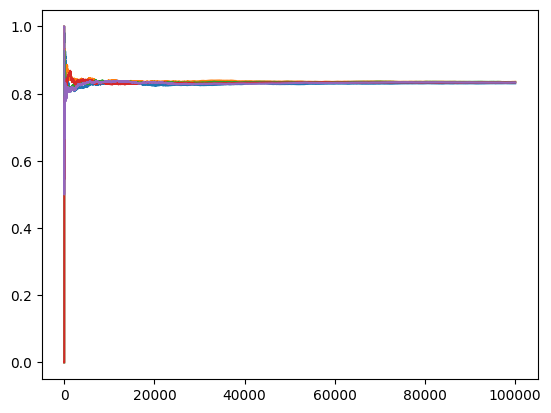

In [66]:
Ps=np.array([Markov()[0] for i in range(5)])
for i in range(5):
    plt.plot(x,Ps[i], label= "sample %d" %i)

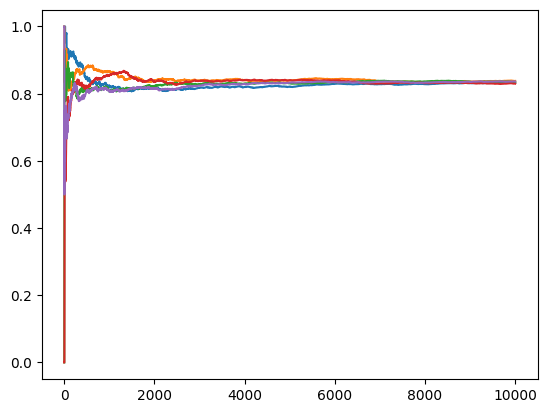

In [70]:
for i in range(5):
    plt.plot(x[:10000],Ps[i][:10000], label= "sample %d" %i)